In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_dir = "../data/processed/train"
val_dir = "../data/processed/val"
test_dir = "../data/processed/test"

In [3]:
train_transforms = transforms.Compose([
    
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(10),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [4]:
val_test_transforms = transforms.Compose([
    
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [5]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=val_test_transforms
)

In [6]:
print(train_dataset.class_to_idx)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


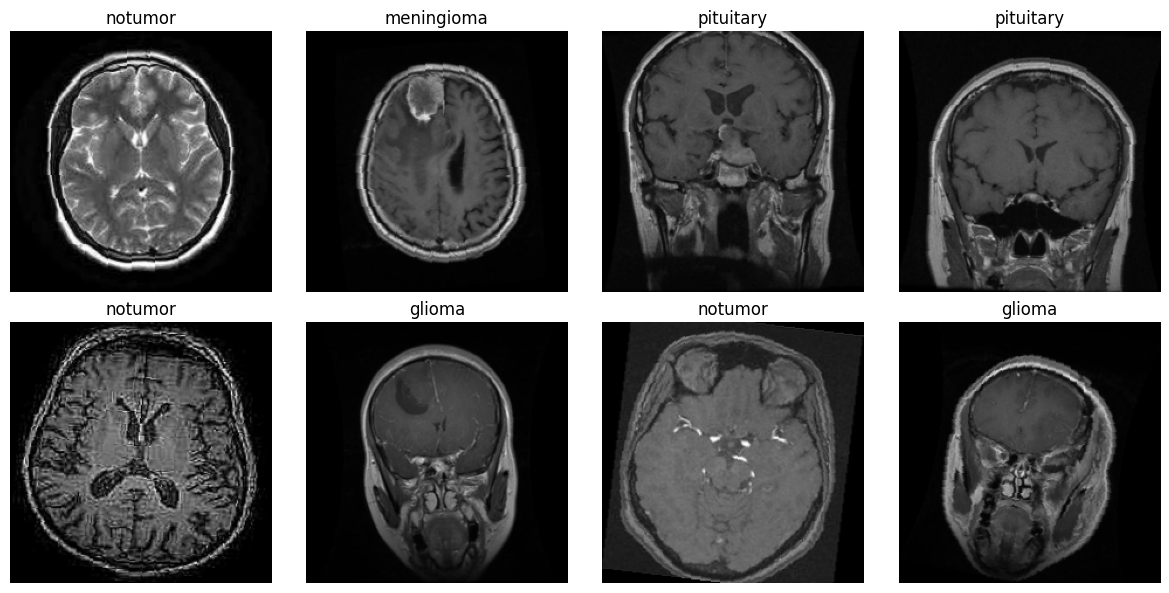

In [9]:
classes = train_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i in range(8):
    
    image = images[i]
    
    image = image / 2 + 0.5
    
    np_image = image.numpy()
    
    axes[i//4, i%4].imshow(np.transpose(np_image, (1,2,0)))
    
    label = labels[i].item()
    
    axes[i//4, i%4].set_title(classes[label])
    
    axes[i//4, i%4].axis('off')

plt.tight_layout()
plt.show()